# 5. Redundancia, fuga de información y síntesis del EDA

Este capítulo cierra la fase exploratoria con tres asuntos que condicionan directamente el diseño del pipeline: la redundancia entre predictores, la revisión de fuga de información y la consolidación de hallazgos.

In [1]:
from config import *

roles = roles_variables()
OBJETIVO = roles["objetivo"]
NUMERICAS = roles["numericas"] + roles["ordinales"]
CATEGORICAS = roles["categoricas"]
BINARIAS = roles["binarias"]

train = leer_tabla("diabetes_train")
assert train.isna().sum().sum() == 0, "El conjunto cargado tiene faltantes"
print(f"Entrenamiento: {len(train):,} pacientes")

Entrenamiento: 79,473 pacientes


## 5.1. Colinealidad entre variables numéricas

Se usa la correlación de Spearman, apropiada para variables que no cumplen normalidad, y se complementa con el factor de inflación de la varianza (VIF), que detecta dependencias lineales múltiples invisibles en un análisis por pares.

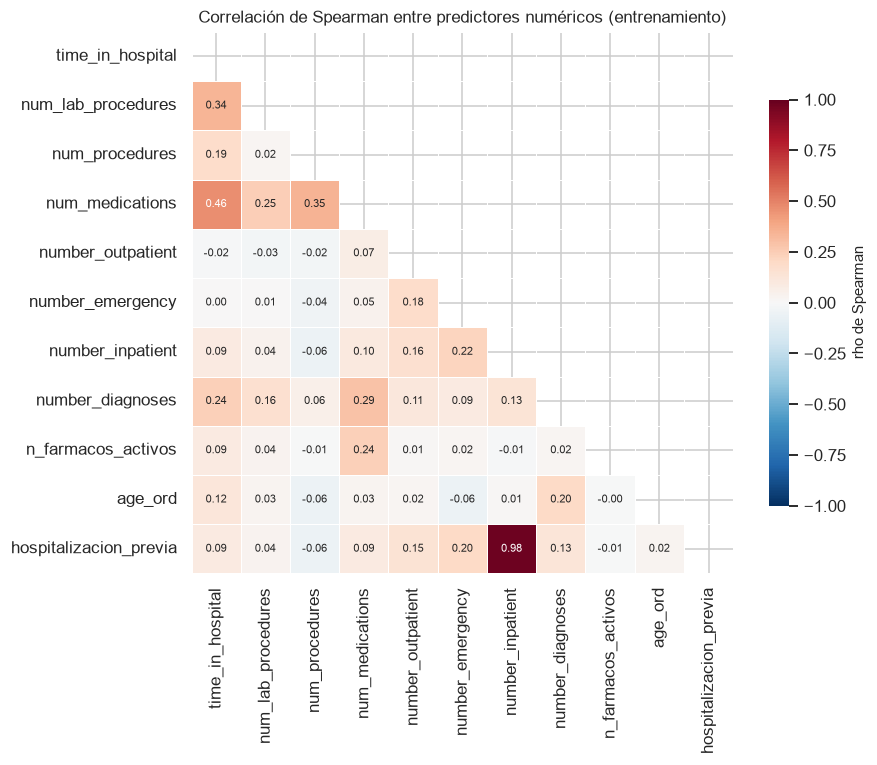

In [2]:
correlaciones = train[NUMERICAS + BINARIAS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.5, 7))
mascara = np.triu(np.ones_like(correlaciones, dtype=bool))
sns.heatmap(correlaciones, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.4,
            cbar_kws={"shrink": 0.75, "label": "rho de Spearman"},
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlación de Spearman entre predictores numéricos "
             "(entrenamiento)")
plt.tight_layout()
plt.show()

In [3]:
pares = (correlaciones
         .where(np.triu(np.ones(correlaciones.shape), k=1).astype(bool))
         .stack().rename("rho").reset_index())
pares.columns = ["variable_1", "variable_2", "rho"]
pares["|rho|"] = pares["rho"].abs()
tabla(pares.query("`|rho|` > 0.25").sort_values("|rho|", ascending=False).round(3),
      filas=15)

In [4]:
def calcular_vif(datos):
    """Factor de inflación de la varianza de cada variable.

    Se define como VIF_j = 1 / (1 - R2_j), donde R2_j proviene de regresar la
    variable j sobre todas las demás con intercepto. Se resuelve por mínimos
    cuadrados para no depender de librerías adicionales.

    Un VIF superior a 5 indica redundancia apreciable y superior a 10,
    colinealidad severa. Valores del orden de 1e12 revelan dependencia lineal
    exacta, es decir, una variable que es combinación de otras.

    Returns
    -------
    pandas.DataFrame
        Variables ordenadas por VIF descendente.
    """
    matriz = np.column_stack([np.ones(len(datos)),
                              datos.astype(float).to_numpy()])
    resultados = []
    for j in range(1, matriz.shape[1]):
        objetivo = matriz[:, j]
        resto = np.delete(matriz, j, axis=1)
        coeficientes, *_ = np.linalg.lstsq(resto, objetivo, rcond=None)
        residuos = objetivo - resto @ coeficientes
        r2 = 1 - residuos.var() / objetivo.var()
        resultados.append(1 / max(1e-12, 1 - r2))
    return (pd.DataFrame({"variable": datos.columns, "VIF": resultados})
            .set_index("variable").sort_values("VIF", ascending=False))


vif = calcular_vif(train[NUMERICAS + BINARIAS])
vif["diagnóstico"] = pd.cut(
    vif["VIF"], bins=[0, 5, 10, np.inf],
    labels=["Aceptable", "Redundancia apreciable", "Colinealidad severa"])
vif.round(2)

,VIF,diagnóstico
variable,,
number_inpatient,2.10,Aceptable
hospitalizacion_previa,2.02,Aceptable
num_medications,1.62,Aceptable
time_in_hospital,1.37,Aceptable
num_procedures,1.21,Aceptable
number_diagnoses,1.18,Aceptable
num_lab_procedures,1.15,Aceptable
number_emergency,1.09,Aceptable
age_ord,1.09,Aceptable


El diagnóstico es benigno: todos los VIF quedan por debajo del umbral de 5, con un máximo de 2.85, y la mayoría cerca de 1.

El par de mayor correlación de Spearman es `number_inpatient` con `hospitalizacion_previa` (rho ≈ 1.00), y merece una lectura cuidadosa para no sacar la conclusión equivocada. La segunda variable es la binarización de la primera, de modo que la relación es monótona perfecta y Spearman, que solo usa rangos, alcanza su valor máximo. Pero eso no implica dependencia lineal: la correlación de Pearson entre ambas es 0.80 y el VIF de las dos se queda en 2.85, dentro de lo aceptable. El valor de Spearman está además inflado por la estructura de empates, ya que el 88 % de las observaciones vale cero en las dos variables. Es un buen recordatorio de que una correlación de rangos cercana a 1 no equivale a redundancia exacta, a diferencia del caso de `visitas_previas` que sí lo era.

Entre variables no derivadas una de otra, la correlación más alta es `time_in_hospital` con `num_medications` (rho ≈ 0.46), seguida de `num_procedures` con `num_medications` (rho ≈ 0.37) y `time_in_hospital` con `num_lab_procedures` (rho ≈ 0.35). El patrón es esperable: las estancias largas acumulan más procedimientos y más fármacos.

Este resultado favorable es consecuencia directa de una corrección aplicada en el capítulo 2. Una versión anterior del conjunto incluía `visitas_previas`, la suma de las tres variables de utilización, junto con sus tres componentes. Eso constituía **dependencia lineal exacta**: el VIF de las cuatro variables se disparaba al orden de 1e12, lo que en la práctica dejaría indeterminados los coeficientes de cualquier modelo lineal. Al conservar solo los componentes, el problema desaparece.

Con este diagnóstico **no se elimina ninguna variable**. La correlación en torno a 0.46 es moderada y no impide estimar un modelo lineal regularizado, que es precisamente el mecanismo con el que Ridge y Lasso manejan la colinealidad.

## 5.2. Redundancia entre variables categóricas

Se calcula la V de Cramér entre pares de categóricas para detectar variables que codifican la misma información.

In [5]:
def v_cramer(contingencia):
    """V de Cramér con la corrección por sesgo de Bergsma."""
    chi2 = stats.chi2_contingency(contingencia).statistic
    n = contingencia.values.sum()
    phi2 = chi2 / n
    r, k = contingencia.shape
    phi2_corregido = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_corregido = r - (r - 1) ** 2 / (n - 1)
    k_corregido = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2_corregido /
                   max(1e-12, min(k_corregido - 1, r_corregido - 1)))


matriz_v = pd.DataFrame(index=CATEGORICAS, columns=CATEGORICAS, dtype=float)
for i, primera in enumerate(CATEGORICAS):
    for segunda in CATEGORICAS[i:]:
        valor = 1.0 if primera == segunda else v_cramer(
            pd.crosstab(train[primera], train[segunda]))
        matriz_v.loc[primera, segunda] = valor
        matriz_v.loc[segunda, primera] = valor

pares_cat = (matriz_v
             .where(np.triu(np.ones(matriz_v.shape), k=1).astype(bool))
             .stack().rename("V de Cramér").reset_index())
pares_cat.columns = ["variable_1", "variable_2", "V de Cramér"]
pares_cat = pares_cat.sort_values("V de Cramér", ascending=False)

guardar_resultado(pares_cat.head(30), "redundancia_categoricas")
tabla(pares_cat.head(15).round(3), filas=15)

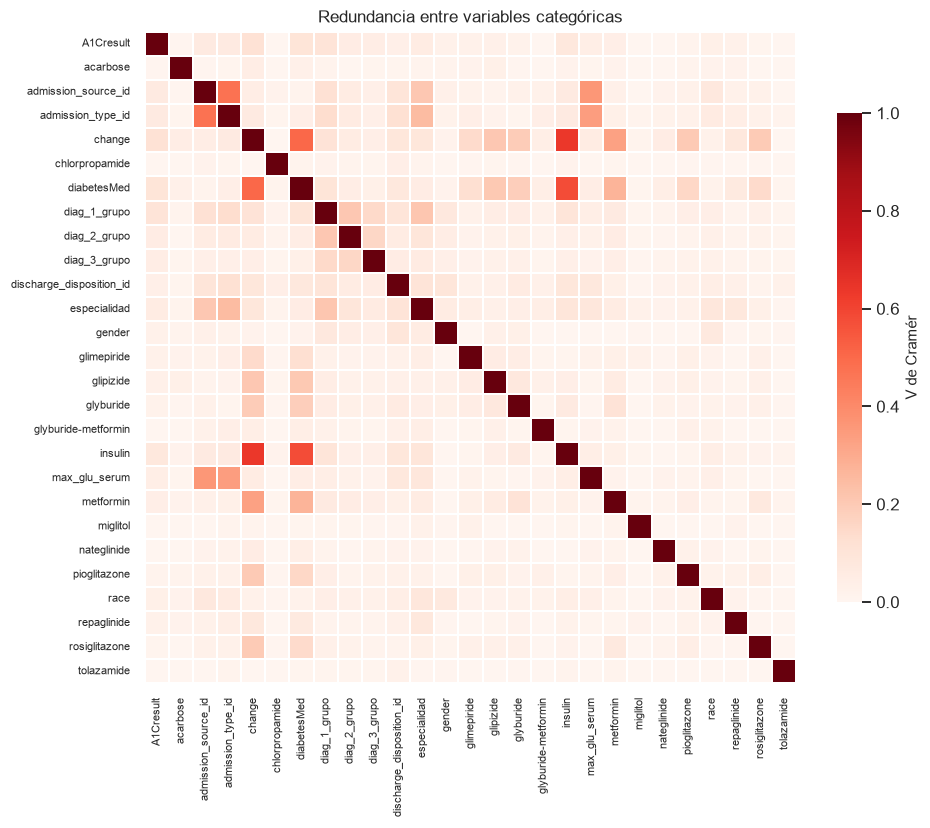

In [6]:
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(matriz_v.astype(float), cmap="Reds", vmin=0, vmax=1, square=True,
            linewidths=0.3, cbar_kws={"shrink": 0.75, "label": "V de Cramér"},
            ax=ax)
ax.set_title("Redundancia entre variables categóricas")
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

Aparece un grupo con redundancia apreciable: `insulin` con `change` (V ≈ 0.61), `insulin` con `diabetesMed` (V ≈ 0.57) y `change` con `diabetesMed` (V ≈ 0.51). Por detrás quedan tres pares de intensidad moderada: los dos identificadores de admisión entre sí (V ≈ 0.42), las dos pruebas de laboratorio (V ≈ 0.36) y `change` con `metformin` (V ≈ 0.36). La explicación del primer grupo es estructural: `diabetesMed` indica si se administró algún fármaco antidiabético, `change` si hubo un cambio de medicación, e `insulin` es el fármaco más prescrito de la cohorte. Las tres describen parcialmente el mismo hecho clínico.

Ninguna V llega a valores extremos como los que indicarían duplicación (por ejemplo, el par `grade`/`sub_grade` en datasets de crédito, con V superior a 0.9), así que las tres se conservan. La observación queda registrada para interpretar con cautela los coeficientes de los modelos lineales y las atribuciones de importancia en ese bloque: la señal se reparte entre variables correlacionadas, lo que puede diluir la importancia individual de cada una sin que eso signifique irrelevancia clínica.

## 5.3. Revisión de fuga de información

Un predictor solo es admisible si su valor está disponible **en el momento del alta**, que es cuando el modelo debería emitir su predicción en un uso real. Se revisa cada bloque bajo ese criterio.

| Bloque | ¿Disponible al alta? | Decisión |
|---|---|---|
| Demográficas (`race`, `gender`, `age_ord`) | Sí, desde el ingreso | Se conservan |
| Administrativas (`admission_type_id`, `admission_source_id`) | Sí, desde el ingreso | Se conservan |
| `discharge_disposition_id` | Sí, se determina al alta | Se conserva. Es el predictor categórico más asociado y su uso es legítimo |
| Utilización previa (`number_outpatient`, `number_emergency`, `number_inpatient`, `hospitalizacion_previa`) | Sí, corresponde al año anterior | Se conservan |
| Proceso del ingreso (`time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses`) | Sí, se conocen al cierre del episodio | Se conservan para la tarea de clasificación |
| Laboratorio (`A1Cresult`, `max_glu_serum`) | Sí | Se conservan, incluida la categoría de prueba no realizada |
| Fármacos, `change`, `diabetesMed`, `n_farmacos_activos` | Sí | Se conservan |
| `readmitted` | **No**: es el desenlace | Eliminada tras derivar el target |
| `patient_nbr` | Identificador | Se conserva solo para trazabilidad y agrupamiento; nunca como predictor |

No hay fuga en sentido estricto entre los predictores de clasificación, a diferencia de otros datasets donde variables posteriores al evento se cuelan entre las entradas. Los dos riesgos reales de este proyecto son de otra naturaleza y ya están tratados: la **dependencia entre encuentros** del mismo paciente (capítulo 1, sección 4.1) y la **estimación de parámetros de preprocesamiento fuera de los folds**, que el pipeline debe evitar.

### 5.3.1. Advertencia para la tarea de regresión

El pipeline experimental incluye una tarea de regresión, y la variable candidata natural es `time_in_hospital`, los días de estancia. Ahí la situación cambia por completo: `num_lab_procedures`, `num_procedures` y `num_medications` son **concurrentes** con la estancia, es decir, se acumulan durante los días de hospitalización. Usarlas para predecir la duración de esa misma estancia es fuga de información, y explica buena parte de las correlaciones observadas en la sección 5.1.

El capítulo de regresión deberá, por tanto, restringir el conjunto de predictores a las variables conocidas en el momento del **ingreso** (demografía, tipo y fuente de admisión, diagnósticos, utilización previa), o bien declarar explícitamente que el ejercicio es descriptivo y no predictivo. La primera opción es la defendible.

Una advertencia adicional sobre las pruebas estadísticas de ese capítulo: los contrastes de White, BDS, Ljung-Box, el conjunto de modelos de confianza y las pruebas de Giacomini-White y Diebold-Mariano están diseñados para **series temporales o secuencias de predicción**. Estos datos son transversales: no hay una ordenación temporal genuina. Aplicar esas pruebas exige ordenar las observaciones por `encounter_id` como aproximación cronológica y declarar el supuesto, o bien adaptar el contraste a pérdidas por observación. En cualquier caso el supuesto debe quedar escrito, no implícito.

## 5.4. Resumen ejecutivo del EDA

| Dimensión | Hallazgo principal |
|---|---|
| **Cohorte final** | 69,987 pacientes únicos y 40 columnas (38 predictores, el target y el identificador), desde 101,766 encuentros y 50 variables originales |
| **Partición** | 55,989 de entrenamiento y 13,998 de prueba, estratificada con semilla 42; todo el EDA bivariado se hizo solo con entrenamiento |
| **Dependencia entre observaciones** | El 23.45 % de los pacientes tiene más de un encuentro y la tasa de readmisión crece del 9.0 % al 23.9 % con la posición del encuentro. Se conserva el primer encuentro por paciente |
| **Desbalance de clases** | 91.02 % frente a 8.98 % (razón 1:10). Descarta la exactitud y justifica la comparación de estrategias de balanceo |
| **Calidad de los datos** | Dos convenciones de faltante (`?` y `None`); sin valores imposibles ni centinelas; 3 registros con género inválido; entre 4.6 % y 10.2 % de códigos administrativos no informativos, conservados como categoría |
| **Exclusiones clínicas** | 2,423 encuentros con alta por fallecimiento u hospicio, cuyo desenlace es imposible por construcción (tasa observada del 1.77 % frente al 11.16 %) |
| **Variables eliminadas** | `weight` (96.9 % faltante), `payer_code` (39.6 %), `encounter_id`, nueve fármacos constantes o cuasi constantes, y `visitas_previas` por dependencia lineal exacta |
| **Alta cardinalidad** | Diagnósticos ICD-9 de 716-789 categorías a 9-10 capítulos clínicos; destino al alta de 21 a 9; especialidad médica de 72 a 11 |
| **Faltantes** | Resueltos con categorías explícitas. `race` no se imputa por ser atributo protegido: imputar la moda atribuiría una pertenencia racial no declarada a 1,917 pacientes |
| **Patrón de nulidad** | Ausencias independientes entre variables; no aleatorias respecto al desenlace, pero con efectos menores a 2 puntos porcentuales |
| **Predictores más asociados** | `discharge_disposition_id` (V ≈ 0.128), `time_in_hospital` (delta de Cliff ≈ 0.125), `age_ord` (≈ 0.097), `number_inpatient` (≈ 0.093) |
| **Tamaños de efecto** | Todos insignificantes según los umbrales de Cliff. Con la corrección de Holm, `num_procedures`, `race`, `admission_source_id` y las dos pruebas de laboratorio dejan de ser significativos. Ningún predictor individual separa las clases |
| **Control glucémico** | Sin capacidad discriminante: intervalos de Wilson solapados y chi² que no sobrevive la corrección de Holm. Posible confusión por indicación, declarada como limitación |
| **Atípicos** | Concentrados en la utilización previa; artefacto de aplicar la regla de Tukey a conteos con exceso de ceros. No se tratan |
| **Normalidad** | Rechazada en todas las numéricas, por construcción más que por el valor p. Implica pruebas no paramétricas y escalado robusto |
| **Colinealidad** | Todos los VIF por debajo de 5 (máximo 2.85) tras eliminar la variable con dependencia exacta. Máxima correlación entre variables independientes: `time_in_hospital` con `num_medications` (rho ≈ 0.46) |
| **Redundancia categórica** | Bloque `insulin`-`change`-`diabetesMed` con V entre 0.51 y 0.61; pares de admisión y de laboratorio en torno a 0.4. Se conservan, con cautela al interpretar importancias |
| **Fuga de información** | Ausente entre los predictores de clasificación. Advertencia registrada para la regresión sobre `time_in_hospital` y para las pruebas de series temporales |

## 5.5. Implicaciones para el modelado

1. **Todo el preprocesamiento va dentro del pipeline.** La codificación de categóricas, el escalado robusto y el balanceo estiman parámetros a partir de los datos. Aplicarlos antes de particionar produce fuga y sobrestima el desempeño. Se implementan como etapas de un `Pipeline` de `imbalanced-learn` ajustado dentro de cada fold de la validación cruzada anidada.

2. **Métricas principales: AUC-ROC y AUC de precisión-exhaustividad**, complementadas con F1 de la clase positiva y exactitud balanceada. La exactitud se reporta solo como referencia, nunca como criterio de selección.

3. **El balanceo se trata como una dimensión experimental**, no como un paso obligatorio: la ausencia de tratamiento es una de las cuatro alternativas y puede ganar.

4. **Las expectativas de desempeño son moderadas y eso es un hallazgo, no una limitación del modelado.** La ausencia de predictores individuales fuertes debe quedar consignada en el artículo antes de presentar los resultados, para que un AUC modesto se interprete correctamente.

5. **Los modelos capaces de capturar interacciones deberían aventajar a los lineales**, dado que la señal no reside en asociaciones marginales. Es una hipótesis contrastable con el diseño experimental previsto, y conviene declararla antes de ejecutarlo.

6. **La colinealidad no exige eliminar variables**, pero sí condiciona la interpretación: en el bloque `insulin`-`change`-`diabetesMed` la importancia se reparte entre variables correlacionadas.

7. **El análisis de sensibilidad con todos los encuentros queda disponible**, ejecutable cambiando un filtro del capítulo 2 y sustituyendo la validación estratificada por `StratifiedGroupKFold` agrupado por `patient_nbr`.